Importing the neccerary libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset

In [2]:
data = pd.read_csv("medical_insurance.csv")

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.shape

(2772, 7)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [6]:
data.isnull().sum()  # checking null values in dataset

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
data.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
data.value_counts("sex")

sex
male      1406
female    1366
Name: count, dtype: int64

In [9]:
data.value_counts("bmi")

bmi
32.300    26
28.310    18
31.350    16
33.330    16
30.800    16
          ..
29.545     2
30.360     2
30.970     2
31.100     2
53.130     2
Name: count, Length: 548, dtype: int64

In [10]:
data.value_counts("region")

region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64

In [11]:
data.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
data.duplicated().sum()

1435

In [13]:
data[data.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.590,0,no,northwest,1639.56310
1338,23,male,34.400,0,no,southwest,1826.84300
1339,56,female,39.820,0,no,southeast,11090.71780
1340,27,male,42.130,0,yes,southeast,39611.75770
1341,19,male,24.600,1,no,southwest,1837.23700
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [14]:
# Drop duplicate values
data =data.drop_duplicates()

In [15]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [16]:
varlist = ["smoker"]
def binary_map(x):
    return x.map({"yes":1,"no":0})

In [17]:
data[varlist] = data[varlist].apply(binary_map)

In [18]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,southwest,16884.92400
1,18,male,33.770,1,0,southeast,1725.55230
2,28,male,33.000,3,0,southeast,4449.46200
3,33,male,22.705,0,0,northwest,21984.47061
4,32,male,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,0,northwest,10600.54830
1334,18,female,31.920,0,0,northeast,2205.98080
1335,18,female,36.850,0,0,southeast,1629.83350
1336,21,female,25.800,0,0,southwest,2007.94500


In [19]:
varlist = ["sex"]
def binary_map(x):
    return x.map({"female":1,"male":0})

In [20]:
data[varlist] = data[varlist].apply(binary_map)

In [21]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [22]:
data = pd.get_dummies(data,columns= ['region'],drop_first = True)

In [23]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [24]:
# Check invalid ages
invalid_age = data[(data['age']<0) | (data['age']>120)]
print(invalid_age)

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, charges, region_northwest, region_southeast, region_southwest]
Index: []


In [25]:
# remove or replace unrealistic ages
data = data[(data['age']>=0) & (data['age'] <=120)]

In [26]:
#check invalid BMI values
invalid_bmi = data[(data['bmi']<10) | (data['bmi'] > 60)]
print(invalid_bmi)

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, charges, region_northwest, region_southeast, region_southwest]
Index: []


In [27]:
#Repalce extrame BMI values with median or remove them
median_bmi = data['bmi'].median()
data.loc[data['bmi']>60, 'bmi'] = median_bmi
data.loc[data['bmi']<10, 'bmi'] = median_bmi

In [28]:
#To improve model performance and interpretability:
def bmi_category(bmi):
    if bmi<18.5:
        return "Underweight"
    if 18.5<= bmi <25:
        return "normal"
    elif 25<= bmi <30:
        return "overweight"
    else:
        return "obese"

In [29]:
data["bmi_category"] = data["bmi"].apply(bmi_category)

In [30]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight


In [31]:
data['smoker_age'] = data['smoker'] * data['age']
data['smoker_bmi'] = data['smoker'] * data['bmi']

In [32]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category,smoker_age,smoker_bmi
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight,19,27.9
1,18,0,33.770,1,0,1725.55230,False,True,False,obese,0,0.0
2,28,0,33.000,3,0,4449.46200,False,True,False,obese,0,0.0
3,33,0,22.705,0,0,21984.47061,True,False,False,normal,0,0.0
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight,0,0.0


In [33]:
#encode the bmi_category
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
data['bmi_category'] = lb.fit_transform(data['bmi_category'])

### Exploratory Data Analysis (EDA) 

#### 1. Univariate Analysis (Single Variable)

### Question-1 What is the distribution of medical insurance charges? 

<Axes: xlabel='charges', ylabel='Count'>

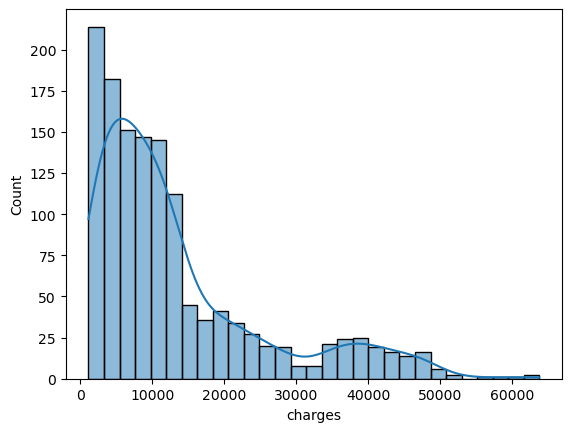

In [34]:
sns.histplot(data['charges'],kde = True)

### Question-2  What is the age distribution of the individuals?

<Axes: xlabel='age', ylabel='Count'>

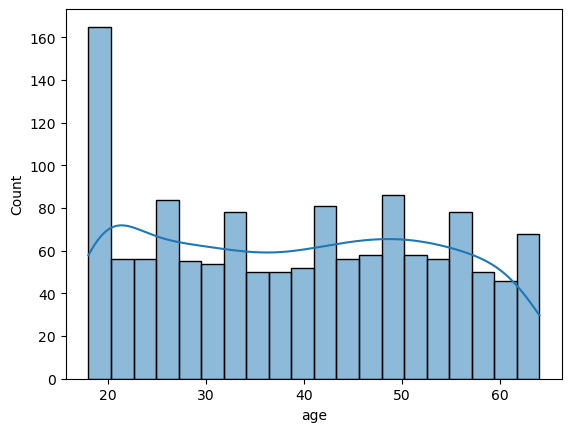

In [35]:
sns.histplot(data['age'],bins=20, kde=True)

### Question-3 How many people are smokers vs non-smokers? 

<Axes: xlabel='smoker', ylabel='count'>

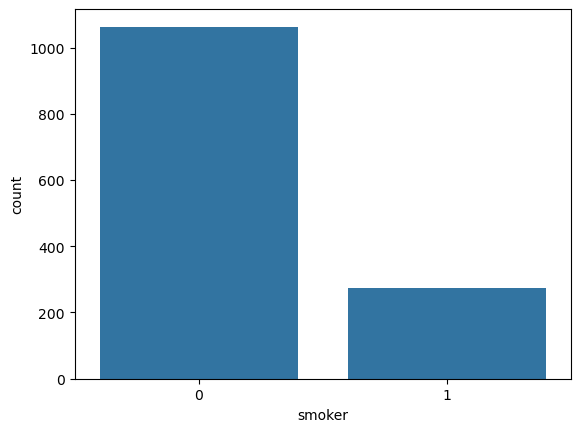

In [36]:
sns.countplot(x='smoker',data =data)

### Question-4 What is the average BMI in the dataset?

<Axes: xlabel='bmi', ylabel='Count'>

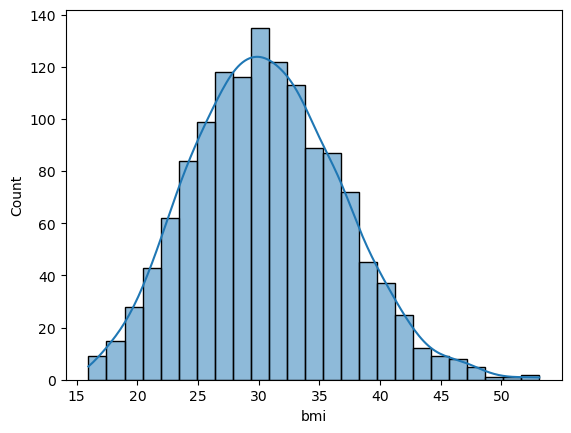

In [37]:
sns.histplot(data['bmi'],kde=True)

### Question-5 Which regions have the most number of policyholders?

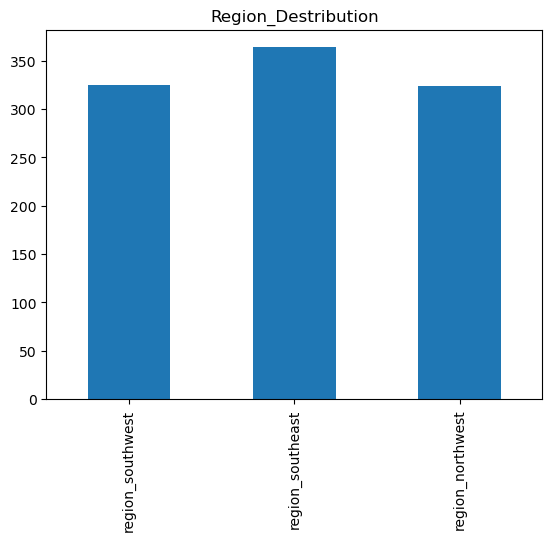

In [38]:
region = ['region_southwest','region_southeast','region_northwest',]
region = data[region].sum()
region.plot(kind='bar')
plt.title('Region_Destribution')
plt.show()



### 2. Bivariate Analysis (Two Variables): 

### Question-1 How do charges vary with age? 

<Axes: xlabel='age', ylabel='charges'>

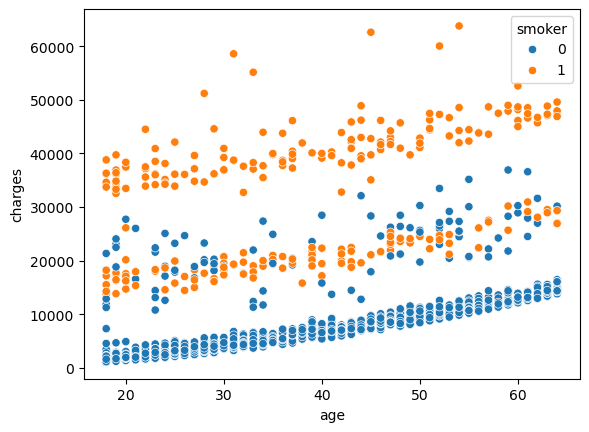

In [39]:
sns.scatterplot(x='age',y='charges',data=data,hue='smoker')

### Question-2 Is there a difference in average charges between smokers and non-smokers?

<Axes: xlabel='smoker', ylabel='charges'>

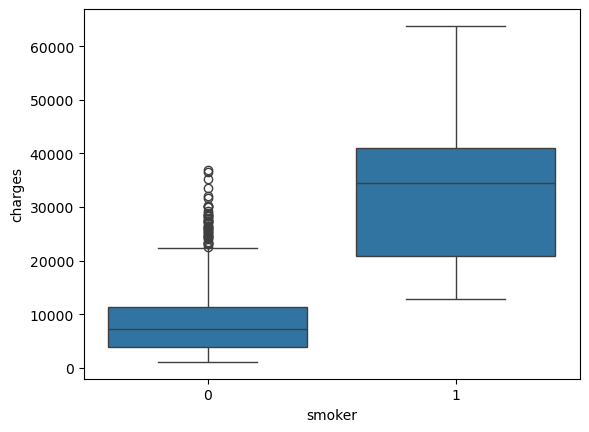

In [40]:
sns.boxplot(x='smoker',y='charges', data=data)

### Question-3 Does BMI impact insurance charges? 


<Axes: xlabel='bmi', ylabel='charges'>

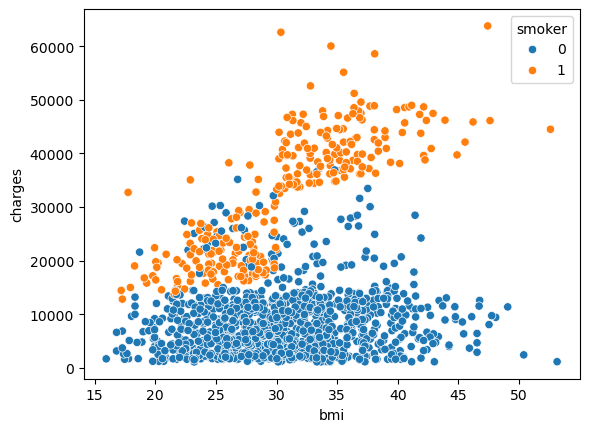

In [41]:
sns.scatterplot(x='bmi',y='charges',data=data,hue='smoker')

### question-4  Do men or women pay more on average? 

<Axes: xlabel='sex', ylabel='charges'>

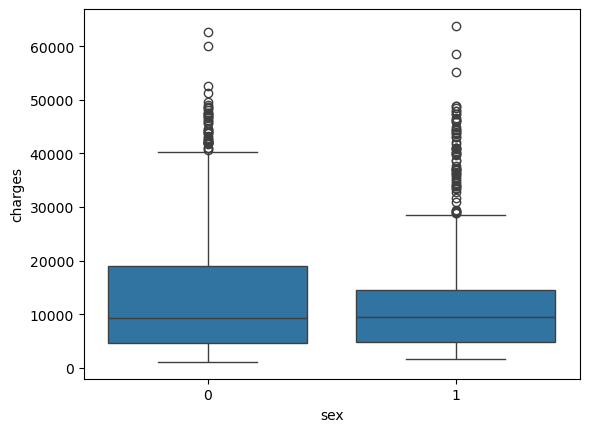

In [42]:
sns.boxplot(x='sex',y='charges',data=data)

### Question-5 Is there a correlation between the number of children and the insurance charges?

<Axes: xlabel='children', ylabel='charges'>

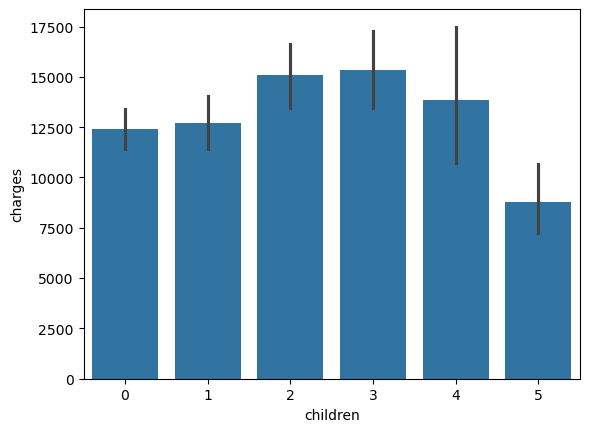

In [43]:
sns.barplot(x='children',y='charges',data=data,estimator=np.mean)

### 3. Multivariate Analysis (More than Two Variables): 

### Question-1 How does smoking status combined with age affect medical charges?

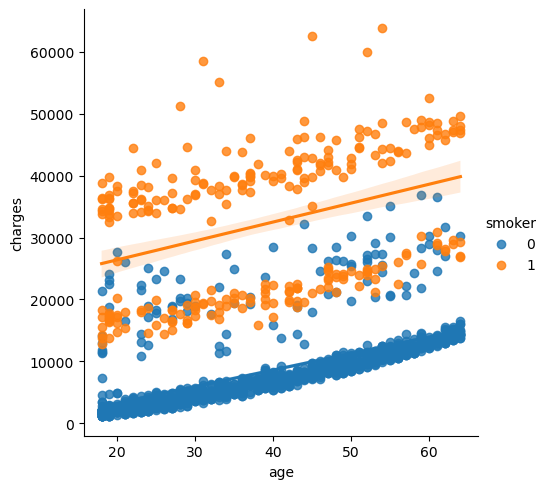

In [44]:
sns.lmplot(x='age',y='charges',hue='smoker',data=data)

### Question-2 How do age, BMI, and smoking status together affect insurance cost?

<Axes: xlabel='bmi', ylabel='charges'>

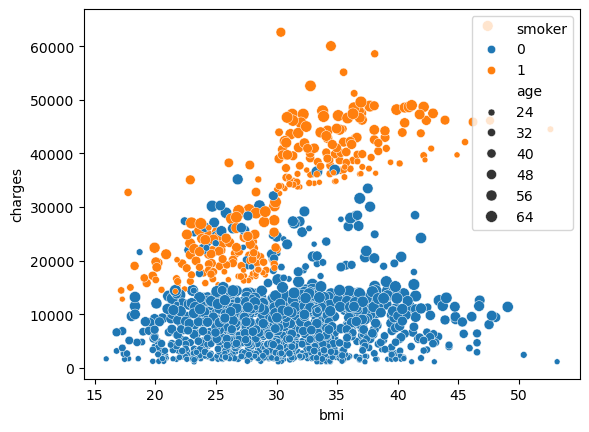

In [45]:
sns.scatterplot(x='bmi',y='charges',hue='smoker',size='age',data=data)

### Question-3 Do obese smokers (BMI > 30) pay significantly higher than non-obese non-smokers? 

In [46]:
data['obese'] = data['bmi']>30
data['obese']

0       False
1        True
2        True
3       False
4       False
        ...  
1333     True
1334     True
1335     True
1336    False
1337    False
Name: obese, Length: 1337, dtype: bool

<Axes: xlabel='smoker', ylabel='charges'>

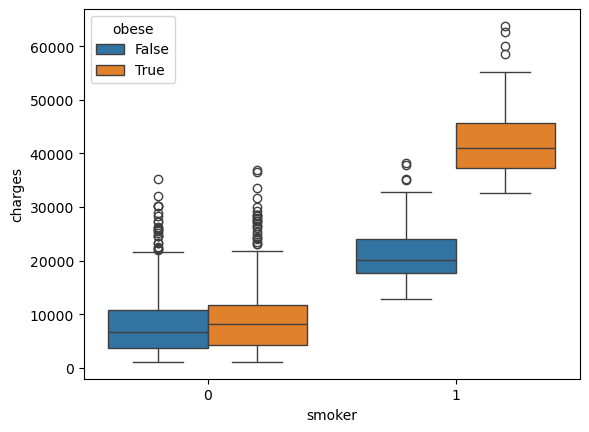

In [47]:
sns.boxplot(x='smoker',y='charges',hue='obese',data=data)

### 4. Outlier Detection: 

### Are there outliers in the charges column? Who are the individuals paying the highest costs? 

<Axes: xlabel='charges'>

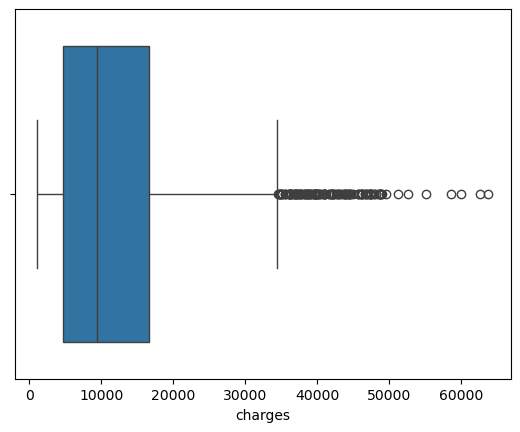

In [48]:
sns.boxplot(x='charges',data=data)

In [49]:
data.sort_values(by='charges',ascending=False).head(10)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category,smoker_age,smoker_bmi,obese
543,54,1,47.410,0,1,63770.42801,False,True,False,2,54,47.410,True
1300,45,0,30.360,0,1,62592.87309,False,True,False,2,45,30.360,True
1230,52,0,34.485,3,1,60021.39897,True,False,False,2,52,34.485,True
577,31,1,38.095,1,1,58571.07448,False,False,False,2,31,38.095,True
819,33,1,35.530,0,1,55135.40209,True,False,False,2,33,35.530,True
1146,60,0,32.800,0,1,52590.82939,False,False,True,2,60,32.800,True
34,28,0,36.400,1,1,51194.55914,False,False,True,2,28,36.400,True
1241,64,0,36.960,2,1,49577.66240,False,True,False,2,64,36.960,True
1062,59,0,41.140,1,1,48970.24760,False,True,False,2,59,41.140,True
488,44,1,38.060,0,1,48885.13561,False,True,False,2,44,38.060,True


### Are there extreme BMI values that could skew predictions? 

<Axes: xlabel='bmi'>

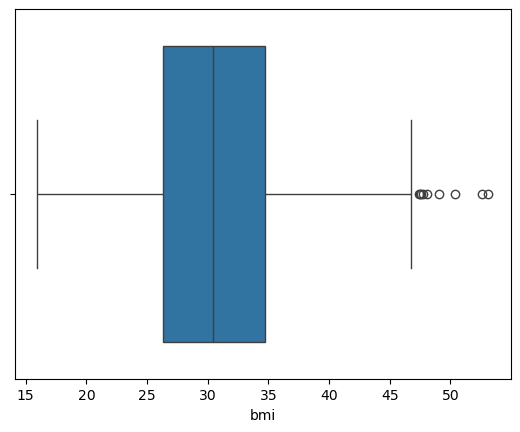

In [50]:
sns.boxplot(x=data['bmi'])

<Axes: xlabel='bmi', ylabel='Count'>

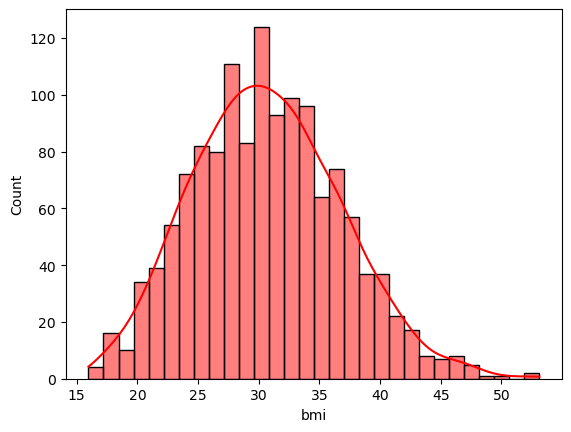

In [51]:
sns.histplot(data['bmi'],bins=30,kde=True,color='red')

### 5. Correlation Analysis: 

### What is the correlation between numeric features like age, BMI, number of children, and charges?

<Axes: >

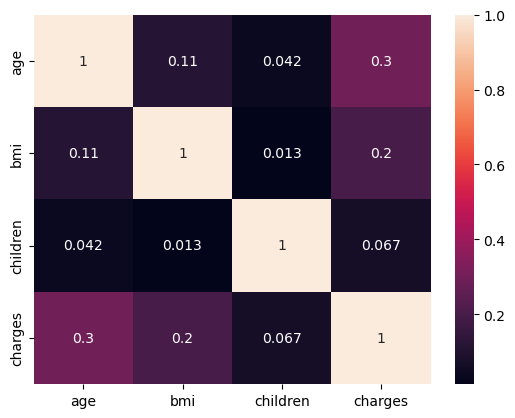

In [52]:
sns.heatmap(data[['age','bmi','children','charges']].corr(),annot=True)

### Which features have the strongest correlation with the target variable (charges)?

In [53]:
data.corr(numeric_only=True)['charges'].sort_values(ascending=False)

charges             1.000000
smoker_bmi          0.845134
smoker_age          0.789253
smoker              0.787234
age                 0.298308
obese               0.200501
bmi                 0.198401
region_southeast    0.073578
children            0.067389
bmi_category       -0.005352
region_northwest   -0.038695
region_southwest   -0.043637
sex                -0.058044
Name: charges, dtype: float64

## Model Training and Evaluation

In [54]:
#Import all required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [55]:
#Define the features (x) and traget (y)
x = data.drop('charges', axis=1)
y = data['charges']

In [56]:
#Split the data into trainging and test sets 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
#train the model
lr = LinearRegression()

In [58]:
#fit the model
lr.fit(x_train,y_train)

LinearRegression()

In [59]:
# predict the model
y_pred = lr.predict(x_test)

In [60]:
#predict the model accuracy 
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [61]:
rme = mean_absolute_error(y_test,y_pred)

In [62]:
r2 = r2_score(y_test,y_pred)

In [63]:
print(rmse)


4550.775540999498


In [64]:
print(rme)

2816.538323080378


In [65]:
print(r2)

0.8872986416386928


In [66]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=0.01),
    'random forest' : RandomForestRegressor(n_estimators=100,random_state=42),
    'XGBoost' : XGBRegressor(n_estimators=100,random_state=42,objective='reg:squarederror')

}

In [67]:
result = {}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)

    result[name] = {'RMSE':rmse, 'MSE':mae, 'R2_Score':r2}


result_data = pd.DataFrame(result).T
result_data = result_data.sort_values(by='RMSE')
print(result_data)

                         RMSE          MSE  R2_Score
Ridge regression  4544.334072  2809.452498  0.887617
Lasso Regression  4550.770468  2816.521646  0.887299
LinearRegression  4550.775541  2816.538323  0.887299
random forest     4719.185242  2678.881026  0.878803
XGBoost           5004.591175  2804.160765  0.863700


### Visualize model comparison

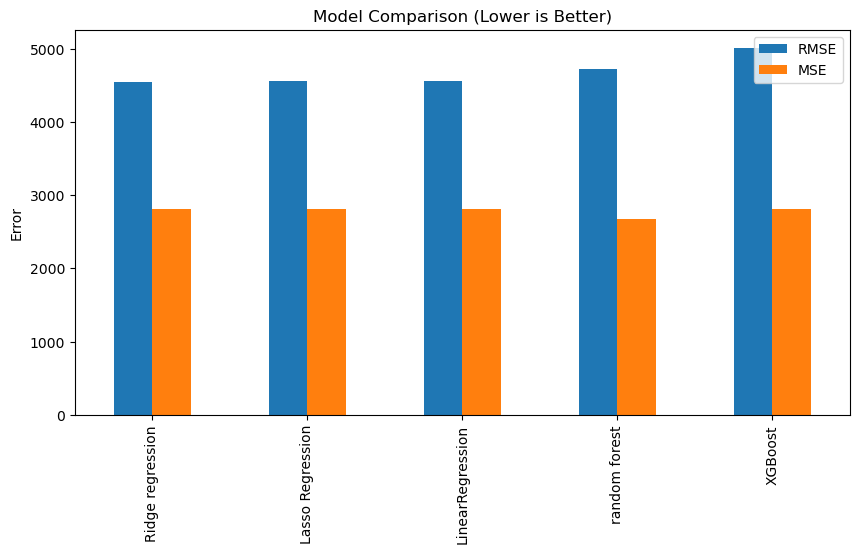

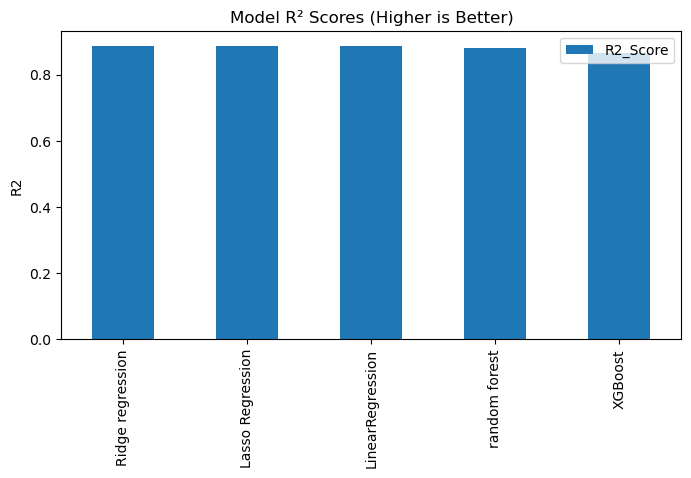

In [68]:
result_data[['RMSE',"MSE"]].plot(kind = 'bar',figsize = (10,5))
plt.title('Model Comparison (Lower is Better)')
plt.ylabel('Error')
plt.show()

result_data[['R2_Score']].plot(kind = 'bar',figsize = (8,4))
plt.title('Model R² Scores (Higher is Better)')
plt.ylabel('R2')
plt.show()

### Find the best model

In [69]:
best_model_name = result_data['RMSE'].idxmin()
print("Best Model Name --->",best_model_name)

Best Model Name ---> Ridge regression


In [70]:

import mlflow 
import json,os,joblib
from mlflow.tracking import MlflowClient
print("mlflow successfully installed")


mlflow successfully installed


In [71]:
Data_path = "medical_insurance.csv"
MODEL_OUTPUT_DIR = "model"
os.makedirs(MODEL_OUTPUT_DIR,exist_ok=True)

MLFLOW_EXPERIMENT_NAME = "Insurance_cost_prediction"
MLFLOW_REGISTERED_NAME = "Insurence_cost_model"

In [72]:
import mlflow.sklearn
mlflow.set_experiment("Medical_Insurance_Cost_Prediction")
client = MlflowClient()

best_rmse = float("inf")
best_run = None
best_model_name = None
best_model_uri = None

#Loop over models, log runs
for name, estimator in models.items():
    with mlflow.start_run(run_name=name) as run:
        run_id = run.info.run_id

        #Train
        estimator.fit(x_train,y_train)
        preds = estimator.predict(x_test)

        #Metrics (y_test, y_pred)
        rmse = float(np.sqrt(mean_squared_error(y_test,preds)))
        mae = float(mean_absolute_error(y_test,preds))
        r2 = float(r2_score(y_test,preds))

        
        #log parameters 
        try:
            params = estimator.get_params()
            # log a small subset to keep UI tidy
            for k in list(params.key())[:10]:
                mlflow.log_param(k,str(params[k]))
        except Exception:
            pass

        #Log metrics
        mlflow.log_metric("test_rmse",rmse)
        mlflow.log_metric("test_mae",mae)
        mlflow.log_metric("test_r2",r2)

        #Log the model artifact (full sklearn estimator)
        mlflow.sklearn.log_model(estimator,artifact_path="model")

        print(f"[run_id={run_id}]{name} -> RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}")

        #Keep best by RMSE
        if rmse < best_rmse:
            best_rmse = rmse
            best_run = run_id
            best_model_name = name
            best_model_uri = f"runs:/{run_id}/model"



# 6) Register the best model in Model Registry 
if best_model_uri is None:
    raise RuntimeError("No model was logged. Check training loop.")

print(f"\nBest run: id={best_run}, model={best_model_name}, rmse={best_rmse:.2f}")
# Create registered model if not exists (safe)
try:
    client.create_registered_model(MLFLOW_REGISTERED_NAME)
    print("Created registered model:", MLFLOW_REGISTERED_NAME)
except Exception:
    # likely already exists
    pass

# Create a new model version from the best run
mv = client.create_model_version(name=MLFLOW_REGISTERED_NAME, source=best_model_uri, run_id=best_run)
print("Registered model version:", mv.version)

# Optionally transition to Production and archive others
try:
    client.transition_model_version_stage(name=MLFLOW_REGISTERED_NAME, version=mv.version, stage="Production", archive_existing_versions=True)
    print(f"Transitioned model {MLFLOW_REGISTERED_NAME} v{mv.version} -> Production")
except Exception as e:
    print("Warning: could not transition model stage:", e)

# 7) Save best model locally for easy loading in Streamlit
# Load model back using mlflow API and save as joblib
best_model_obj = mlflow.sklearn.load_model(best_model_uri)
local_model_path = os.path.join(MODEL_OUTPUT_DIR, f"best_pipeline_{best_model_name}.joblib")
joblib.dump(best_model_obj, local_model_path)
print("Saved best model locally to:", local_model_path)

# 8) Save metrics.json to be used by Streamlit app (optional)
metrics_out = {
    "model_name": best_model_name,
    "best_run_id": best_run,
    "test_rmse": best_rmse,
    "test_mae": mae,
    "test_r2": r2
}
with open(os.path.join(MODEL_OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics_out, f, indent=2)
print("Saved metrics.json ->", os.path.join(MODEL_OUTPUT_DIR, "metrics.json"))

print("\nMLflow logging & registry steps completed.")




2026/04/04 20:53:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/04 20:53:36 INFO mlflow.store.db.utils: Updating database tables
2026/04/04 20:53:39 INFO mlflow.tracking.fluent: Experiment with name 'Medical_Insurance_Cost_Prediction' does not exist. Creating a new experiment.
2026/04/04 20:53:39 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or excep

[run_id=be2922bda75b4fbdb80943c1a4180a5e]LinearRegression -> RMSE=4550.78, MAE=2816.54, R2=0.8873


2026/04/04 20:53:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 20:54:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[run_id=52b36f9a17204e4f99db6f06eb2b5be1]Ridge regression -> RMSE=4544.33, MAE=2809.45, R2=0.8876


2026/04/04 20:54:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

[run_id=72a878dfc6264f27b17ccaad59368ce1]random forest -> RMSE=4719.19, MAE=2678.88, R2=0.8788


2026/04/04 20:54:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 20:54:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[run_id=65720d00bf4d4ba2ae7a7172634e4393]XGBoost -> RMSE=5004.59, MAE=2804.16, R2=0.8637

Best run: id=52b36f9a17204e4f99db6f06eb2b5be1, model=Ridge regression, rmse=4544.33
Created registered model: Insurence_cost_model
Registered model version: 1
Transitioned model Insurence_cost_model v1 -> Production


C:\Users\sheik\AppData\Local\Temp\ipykernel_16820\662967109.py:72: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(name=MLFLOW_REGISTERED_NAME, version=mv.version, stage="Production", archive_existing_versions=True)


Saved best model locally to: model\best_pipeline_Ridge regression.joblib
Saved metrics.json -> model\metrics.json

MLflow logging & registry steps completed.


In [73]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=0.01),
    'random forest' : RandomForestRegressor(n_estimators=100,random_state=42),
    'XGBoost' : XGBRegressor(n_estimators=100,random_state=42,objective='reg:squarederror')
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(x_train,y_train)
        y_pred = model.predict(x_test)

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test,y_pred))
        mae = mean_absolute_error(y_test,y_pred)
        r2 = r2_score(y_test,y_pred)

        # Log parameters and metrics
        mlflow.log_param("model_name", name)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2_score", r2)

        # Log the model
        mlflow.sklearn.log_model(model,name)

        print(f"Logged {name}--> RMSE: {rmse:.2f}, R2: {r2:.4f}")




2026/04/04 20:54:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 20:54:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 20:55:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged LinearRegression--> RMSE: 4550.78, R2: 0.8873


2026/04/04 20:55:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 20:55:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged Ridge regression--> RMSE: 4544.33, R2: 0.8876


2026/04/04 20:55:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged Lasso Regression--> RMSE: 4550.77, R2: 0.8873


2026/04/04 20:55:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 20:55:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged random forest--> RMSE: 4719.19, R2: 0.8788


2026/04/04 20:55:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 20:55:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged XGBoost--> RMSE: 5004.59, R2: 0.8637


In [74]:
# Save the model locally using joblib
import joblib,os,pprint
path = "model/best_pipeline_Ridge Regression.joblib"
print("exists:", os.path.exists(path))
obj = joblib.load(path)
print("Loaded object type:", type(obj))

#If it's a dict, show key and values types
if isinstance(obj, dict):
    print("Dict keys and value types:")
    for k,v in obj.items():
        print(" -", k, "-", type(v))
    pprint.pprint(list(obj.keys()))
else:
    #Try to predict with the loaded object
    has_predict = hasattr(obj, "predict")
    print("Has predict attribute?:", has_predict)
    # If it's a sklearn pipeline, show steps
    try:
        if hasattr(obj, "named_steps"):
            print("Pipeline steps:", list(obj.named_steps.keys()))
    except Exception as e:
        print("Error checking pipeline steps:", e)  
            

exists: True
Loaded object type: <class 'sklearn.linear_model._ridge.Ridge'>
Has predict attribute?: True


In [75]:
import joblib, pandas as pd
m = joblib.load("model/best_pipeline_Ridge Regression.joblib")
print("Model loaded successfully. Type:", type(m))

sample = pd.DataFrame([{"age":40,"sex":"male","bmi":30.5,"children":2,"smoker":"yes","region":"southeast"}])

#Prepocessing the sample data
sample['smoker'] = sample['smoker'].map({"yes":1,"no":0})
sample['sex'] = sample['sex'].map({"male":0,"female":1})
sample = pd.get_dummies(sample, columns=['region'], drop_first=True)

#Add engineered features to the sample data
def bmi_category(bmi):
    if bmi<18.5:
        return "Underweight"
    if 18.5<= bmi <25:
        return "normal"
    elif 25<= bmi <30:
        return "overweight"
    else:
        return "obese"
    
sample["bmi_category"] = sample["bmi"].apply(bmi_category)

from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
sample['bmi_category'] = lb.fit_transform(sample['bmi_category'])

sample['smoker_age'] = sample['smoker'] * sample['age']
sample['smoker_bmi'] = sample['smoker'] * sample['bmi']

#Ensure columns are in the same order as training data and handle missing columns
sample = sample.reindex(columns=x_train.columns, fill_value=0)

print("Sample Prediction:", m.predict(sample))

Model loaded successfully. Type: <class 'sklearn.linear_model._ridge.Ridge'>
Sample Prediction: [31065.73346215]


In [ ]:
%%writefile medical_insurance_app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
from sklearn.preprocessing import LabelEncoder

# Sidebar Navigation
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go To", [
    "Project Introduction", "Insurance Prediction", "Exploratory Data Analysis (EDA)"
])

if page == "Project Introduction":
    st.title("🏥 Medical Insurance Cost Prediction")
    
    st.markdown("""
    ### 📌 Project Overview
    
    I built this project to predict medical insurance costs based on personal health and demographic information. 
    The model takes inputs like age, BMI, smoking status, number of children, and region to estimate annual insurance charges.
    
    This kind of tool can help insurance companies determine personalized premiums, and also help individuals understand 
    what factors affect their insurance costs.
    
    ---
    
    ### 🎯 Problem Statement
    
    The dataset contained information about insurance policy holders - their age, gender, BMI, smoking habits, 
    family details, location, and the actual medical charges they paid.
    
    My task was to analyze this data and build a regression model that could predict insurance costs for new users 
    based on their personal information.
    
    ---
    
    ### 📊 Dataset
    
    After cleaning the data (removing duplicates), I had **1,337 records** to work with.
    
    **Original Features:**
    - `age` - Age of the person
    - `sex` - male or female
    - `bmi` - Body Mass Index
    - `children` - Number of dependents
    - `smoker` - yes or no
    - `region` - northeast, northwest, southeast, southwest
    - `charges` - **Target variable** (what I needed to predict)
    
    **Features I Created:**
    - `bmi_category` - Underweight, normal, overweight, obese
    - `smoker_age` - smoker × age (interaction feature)
    - `smoker_bmi` - smoker × bmi (interaction feature)
    - `obese` - flag for BMI > 30
    
    ---
    
    ### 🤖 Model Training
    
    I trained and compared **5 different regression models**:
    
    | Model | RMSE | R² Score |
    |-------|------|----------|
    | Ridge Regression | $4,544 | 0.888 |
    | Linear Regression | $4,551 | 0.887 |
    | Lasso Regression | $4,551 | 0.887 |
    | Random Forest | $4,719 | 0.879 |
    | XGBoost | $5,005 | 0.864 |
    
    **Ridge Regression** performed the best, so I selected it as my final model and deployed it in this app.
    
    ---
    
    ### 💡 What I Learned from the Data
    
    Some interesting patterns I found during analysis:
    
    - **Smoking is the biggest factor** - Smokers pay 3-4 times more than non-smokers
    - **Obese smokers (BMI > 30)** have the highest insurance costs
    - **Age** increases costs, but not as dramatically as smoking
    - **Gender and region** have almost no impact on charges
    - **Number of children** also doesn't affect costs much
    
    """)


elif page == "Insurance Prediction":
    st.title("Medical Insurance Cost Prediction")

    # Load the best model
    model_path = "model/best_pipeline_Ridge Regression.joblib"
    metrics_path = "model/metrics.json"

    # Load model and metrics
    try:
        model = joblib.load(model_path)
        st.success(f"Model loaded successfully from {model_path}")
    except Exception as e:
        st.error(f"Error in model loading from {model_path}: {e}")
        st.stop()

    # Load metrics
    metrics = None
    if os.path.exists(metrics_path):
        try:
            with open(metrics_path, "r") as f:
                metrics = json.load(f)
            st.info("Loaded metrics.json — will use reported RMSE/MAE to show approximate error margins.")
        except Exception as e:
            st.warning(f"Could not load metrics.json: {e}")
    else:
        st.info("No metrics.json found. The app will not show error margins if desired.")


    st.subheader("Enter Your Information")


    age = st.number_input("Age", min_value=18, max_value=120, value=30)
    sex = st.selectbox("Sex", options=["male", "female"])
    bmi = st.number_input("BMI", min_value=10.0, max_value=50.0, value=25.0)
    children = st.number_input("Number of Children", min_value=0, value=0)
    smoker = st.selectbox("Smoker", options=["yes", "no"])
    region = st.selectbox("Region", options=["northeast", "northwest", "southeast", "southwest"])

    # Show confidence intervals / error margins
    show_CI = st.checkbox("Show approximate 95% confidence interval / error margin (if metrics available)", value=True)
    use_fallback_percentage = st.slider("If metrics not available, use fallback relative error (%)", min_value=5, max_value=100, value=20)

    # Create a DataFrame for the input
    input_data = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "bmi": bmi,
        "children": children,
        "smoker": smoker,
        "region": region
    }])

    # Apply binary encoding for 'sex', 'smoker' and one-hot encoding for 'region'
    input_data['smoker'] = input_data['smoker'].map({"yes":1,"no":0})
    input_data['sex'] = input_data['sex'].map({"male":0,"female":1})
    input_data = pd.get_dummies(input_data, columns=['region'], drop_first=True)

    # Define the same feature engineering steps as in training
    def bmi_category(bmi):
        if bmi<18.5:
            return "Underweight"
        if 18.5<= bmi <25:
            return "normal"
        elif 25<= bmi <30:
            return "overweight"
        else:
            return "obese"

    input_data["bmi_category"] = input_data["bmi"].apply(bmi_category)
    lb = LabelEncoder()
    input_data['bmi_category'] = lb.fit_transform(input_data['bmi_category'])

    input_data['smoker_age'] = input_data['smoker'] * input_data['age']
    input_data['smoker_bmi'] = input_data['smoker'] * input_data['bmi']

    # Ensure the input data has the same columns as the training data
    # This is crucial for the model to work correctly
    try:
        input_data = input_data.reindex(columns=model.feature_names_in_, fill_value=0)
    except Exception as e:
        st.error(f"Error aligning input features with model features: {e}")
        st.stop()   

    st.write("Preprocessed Input Data:")
    st.dataframe(input_data)

    # Make prediction when button is clicked
    if st.button("Predict Insurance Cost"):
        try:
            prediction = model.predict(input_data)[0]
        except Exception as e:
            st.error(f"Failed to make prediction: {e}")
            st.stop()

        #Determine an uncertainty estimate
        uncertainty = None
        method_used = None
        if metrics and show_CI:
            if "test_rmse" in metrics:
                uncertainty = float(metrics["test_rmse"])
                method_used = "RMSE"
            elif "test_mae" in metrics:
                uncertainty = float(metrics["test_mae"])
                method_used = "MAE"

        if show_CI and uncertainty is None:
            uncertainty = abs(prediction) * (use_fallback_percentage / 100.0)
            method_used = f"Fallback {use_fallback_percentage}%"

        st.subheader("Predicted Annual Insurance Cost:")
        st.write(f"${prediction:,.2f}")

        if show_CI and uncertainty is not None:
            ci_lower = prediction - 1.96 * uncertainty
            ci_upper = prediction + 1.96 * uncertainty
            st.info(f" Using **{method_used}** for uncertainty estimate")
            st.write(f"**95% Confidence Interval:** ${max(0, ci_lower):,.2f} — ${ci_upper:,.2f}")


        # Show a warning so users understand the interval
        st.markdown("---")
        st.write("**Note:** The interval shown is an approximate error margin. The app uses a saved training metric (if available) such as RMSE/MAE to produce a rough 95% interval. If no metric is available, a user-selected fallback percentage is used. For statistically rigorous prediction intervals you would need access to residuals/variance information from the training procedure or use probabilistic models (e.g., Bayesian models) or techniques like conformal prediction or bootstrapping saved at training time.")


        

elif page == "Exploratory Data Analysis (EDA)":
    st.subheader("Exploratory Data Analysis (EDA)")

    df = pd.read_csv("medical_insurance.csv")
    df.head()


    # Plot 1: Age vs. Charges
    st.write("#### Age vs. Charges")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(x='age', y='charges', data=df, ax=ax)
    st.pyplot(fig)
    st.write("This scatter plot shows the relationship between age and medical insurance charges. Generally, charges tend to increase with age.")

    # Plot 2: BMI vs. Charges
    st.write("#### BMI vs. Charges")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(x='bmi', y='charges', data=df, ax=ax)
    st.pyplot(fig)
    st.write("This scatter plot illustrates the relationship between Body Mass Index (BMI) and medical insurance charges. Higher BMI often correlates with higher charges.")

    # Plot 3: Smoker vs. Charges
    st.write("#### Smoking Status vs. Charges")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(x='smoker', y='charges', data=df, ax=ax)
    st.pyplot(fig)
    st.write("This box plot compares the distribution of medical insurance charges for smokers (1) and non-smokers (0). Smokers typically have significantly higher charges.")

    # Plot 4: Region vs. Charges
    st.write("#### Region vs. Charges")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(x='region', y='charges', data=df, ax=ax)
    st.pyplot(fig)
    st.write("This box plot shows how medical insurance charges vary across different regions.")




Overwriting medical_insurance_app.py


In [2]:
!streamlit run medical_insurance_app.py

^C
